In [55]:
import rocketpy
from datetime import datetime, timedelta
thrust_curve = "../data/motor_file/AeroTech_M2400T.eng"

https://docs.rocketpy.org/en/latest/user/rocket/rocket.html


Gravity Details

Acceleration of gravity at surface level:    9.8014 m/s²
Acceleration of gravity at  13.606 km (ASL): 9.7602 m/s²


Launch Site Details

Launch Date: 2026-05-04 03:55:28 UTC | 2026-05-03 23:55:28 America/New_York
Launch Site Latitude: 40.38677°
Launch Site Longitude: -87.51128°
Reference Datum: SIRGAS2000
Launch Site UTM coordinates: 456604.17 W    4470812.02 N
Launch Site UTM zone: 16T
Launch Site Surface Elevation: 213.0 m


Atmospheric Model Details

Atmospheric Model Type: windy
windy Maximum Height: 13.606 km

Surface Atmospheric Conditions

Surface Wind Speed: 8.67 m/s
Surface Wind Direction: 214.30°
Surface Wind Heading: 34.30°
Surface Pressure: 986.40 hPa
Surface Temperature: 286.45 K
Surface Air Density: 1.200 kg/m³
Surface Speed of Sound: 339.29 m/s


Earth Model Details

Earth Radius at Launch site: 6369.20 km
Semi-major Axis: 6378.14 km
Semi-minor Axis: 6356.75 km
Flattening: 0.0034


Atmospheric Model Plots



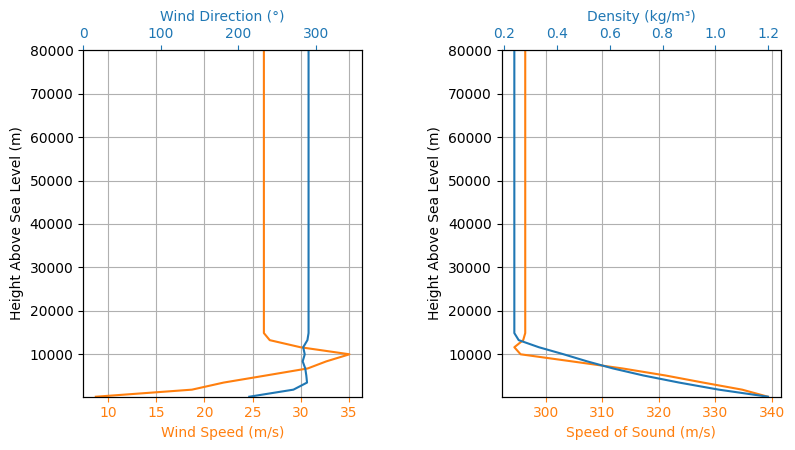

In [ ]:
tomorrow = datetime.now() + timedelta(days=1)

env = rocketpy.Environment(
    latitude= 40.386772,
    longitude= -87.511283,
    elevation= 216.10,
    #date = tomorrow,
    date=datetime(2026, 4, 19, 12, 58, 0),
    timezone="America/New_York"
)


env_custom_atm = rocketpy.Environment()
env_custom_atm.set_atmospheric_model(
    type="custom_atmosphere",
    pressure=None,
    temperature=300,
    wind_u=7.15,  # 16 mph = 7.15 m/s
    wind_v=0,
)

env.set_atmospheric_model(type="windy", file="GFS")##(type="standard_atmosphere")##, file="GFS")

env.info()




In [169]:
#calculated from ORK component mass distribution and simulation data
Control_Freak = rocketpy.Rocket(
    radius = 0.131/2,    #m
    
    #to be updated
    mass   = 14.1067,     #kg dry mass
    inertia= (8.27, 8.27, 0.056), #Pitch, Yaw, Roll in kg*m^2

    power_off_drag= '../data/drag/CD_Power-off.csv', #m^2, from RASAero simulation
    power_on_drag='../data/drag/CD_Power-on.csv', #m^2, from RASAero simulation
    center_of_mass_without_motor=1.5875, #m from nose tip
    coordinate_system_orientation="nose_to_tail",
 )

#AeroTech M2400T / RMS-98/7680

"""AeroTech_M2400T.eng"""


nose_cone = Control_Freak.add_nose(
    length=0.724, #m
    kind="von karman",
    position=0
)

#main fins
fin_set = Control_Freak.add_trapezoidal_fins(
    n=4,
    root_chord=0.305,
    tip_chord=0.152,
    span=0.133,
    position=2.459,
    cant_angle=0,
    airfoil=None,
    sweep_length = 0.234 
)

#canards
canards = Control_Freak.add_trapezoidal_fins(
    n=2,
    root_chord=0.0508,
    tip_chord=0.0127,
    span=0.0635,
    position=1.04,
    sweep_angle = 0.001,
    cant_angle = 0,
)

tail = Control_Freak.add_tail(
    top_radius = 0.131/2,
    bottom_radius = 0.102/2,
    length = 0.0762,
    position = 2.7938,
)




rail_buttons = Control_Freak.set_rail_buttons(
    upper_button_position=1.727,
    lower_button_position=2.692,
    angular_position=45,
)

drogue = Control_Freak.add_parachute(
    name="Drogue",
    cd_s=0.684,
    trigger="apogee",
    sampling_rate=105,
)

main = Control_Freak.add_parachute(
    name="Main",
    cd_s=10.27,
    trigger=304.8,
    sampling_rate=105,

)






In [170]:
motor = rocketpy.SolidMotor(
    thrust_source=thrust_curve,
    dry_mass=2.799,
    dry_inertia=(0.08481, 0.08481, 0.00336),  # (I_11, I_22, I_33)
    nozzle_radius=0.024,
    grain_number=3,
    grain_density=1672.16,
    grain_outer_radius=0.04153,
    grain_initial_inner_radius=0.01429,
    grain_initial_height=0.1524,
    grain_separation=0.005,
    grains_center_of_mass_position=0.2985,
    center_of_dry_mass_position=0.2985,
    nozzle_position=0,
    burn_time= 3.28,
    throat_radius=0.0127,
    coordinate_system_orientation="nozzle_to_combustion_chamber",)

Nozzle Details
Nozzle Radius: 0.024 m
Nozzle Throat Radius: 0.0127 m

Grain Details
Number of Grains: 3
Grain Spacing: 0.005 m
Grain Density: 1672.16 kg/m3
Grain Outer Radius: 0.04153 m
Grain Inner Radius: 0.01429 m
Grain Height: 0.1524 m
Grain Volume: 0.001 m3
Grain Mass: 1.217 kg

Motor Details
Total Burning Time: 3.28 s
Total Propellant Mass: 3.652 kg
Structural Mass Ratio: 0.434
Average Propellant Exhaust Velocity: 2086.627 m/s
Average Thrust: 2323.282 N
Maximum Thrust: 2695.807 N at 1.203 s after ignition.
Total Impulse: 7620.363 Ns



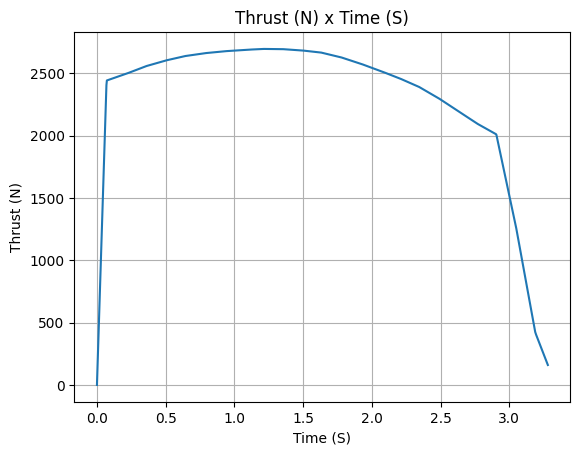

In [171]:
motor.info()

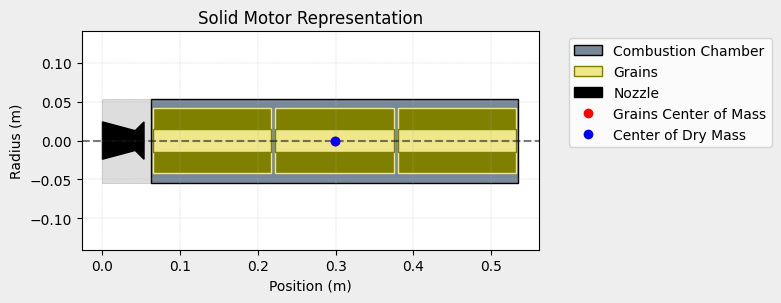

In [172]:
motor.draw()
Control_Freak.add_motor(motor, position=2.870) #m from nose tip


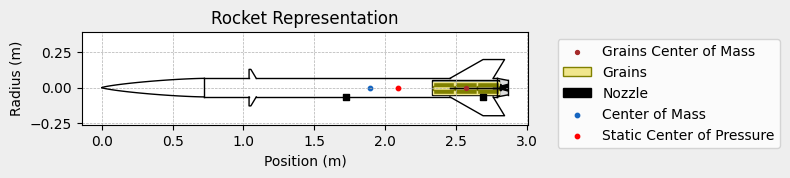

In [173]:
Control_Freak.draw()


Inertia Details

Rocket Mass: 14.107 kg (without motor)
Rocket Dry Mass: 16.906 kg (with unloaded motor)
Rocket Loaded Mass: 20.558 kg
Rocket Structural Mass Ratio: 0.822
Rocket Inertia (with unloaded motor) 11: 10.616 kg*m2
Rocket Inertia (with unloaded motor) 22: 10.616 kg*m2
Rocket Inertia (with unloaded motor) 33: 0.059 kg*m2
Rocket Inertia (with unloaded motor) 12: 0.000 kg*m2
Rocket Inertia (with unloaded motor) 13: 0.000 kg*m2
Rocket Inertia (with unloaded motor) 23: 0.000 kg*m2

Geometrical Parameters

Rocket Maximum Radius: 0.0655 m
Rocket Frontal Area: 0.013478 m2

Rocket Distances
Rocket Center of Dry Mass - Center of Mass without Motor: 0.163 m
Rocket Center of Dry Mass - Nozzle Exit: 1.120 m
Rocket Center of Dry Mass - Center of Propellant Mass: 0.821 m
Rocket Center of Mass - Rocket Loaded Center of Mass: 0.146 m


Aerodynamics Lift Coefficient Derivatives

Nose Cone Lift Coefficient Derivative: 2.000/rad
Fins Lift Coefficient Derivative: 0.855/rad
Fins Lift Coefficient 

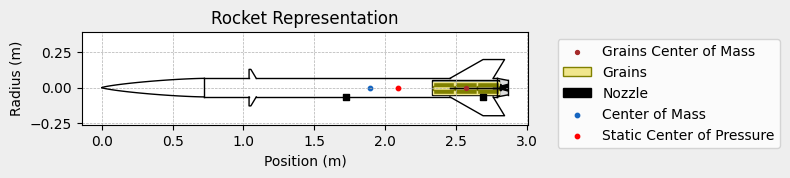


Mass Plots
----------------------------------------


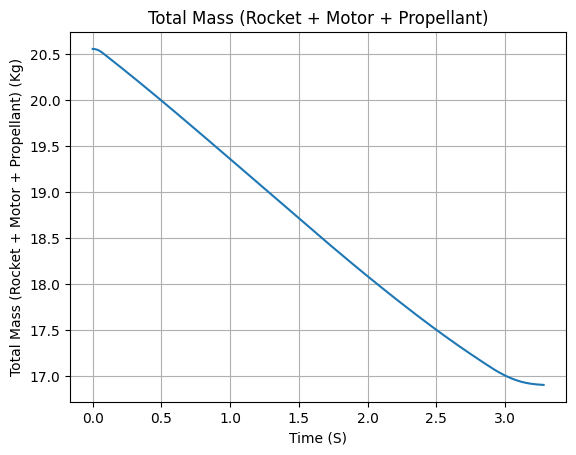

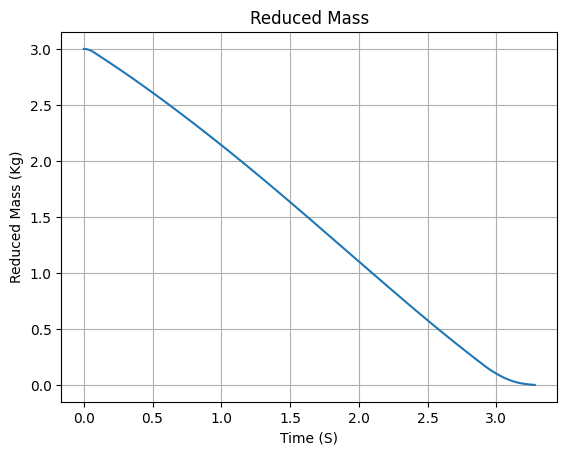


Aerodynamics Plots
----------------------------------------
Drag Plots
--------------------


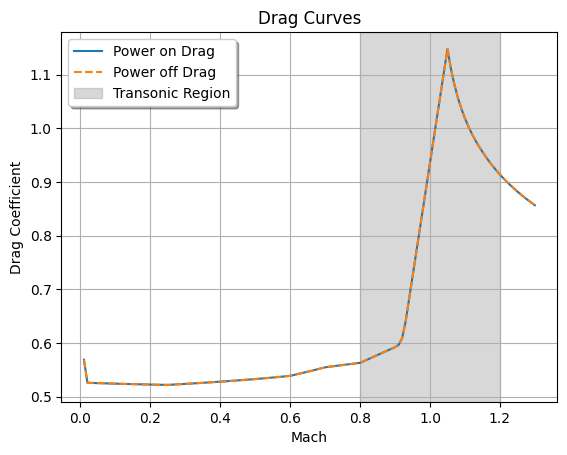


Stability Plots
--------------------


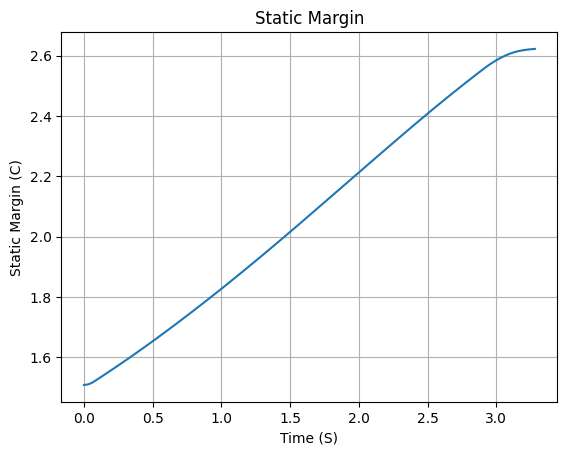

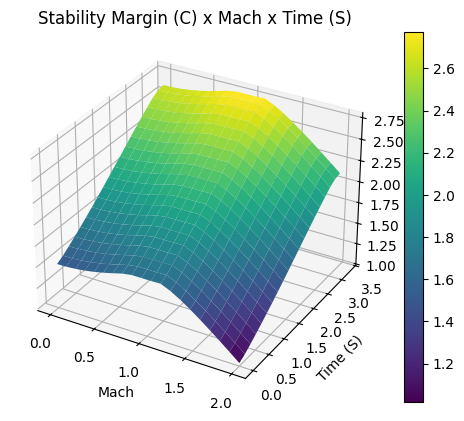


Thrust-to-Weight Plot
----------------------------------------


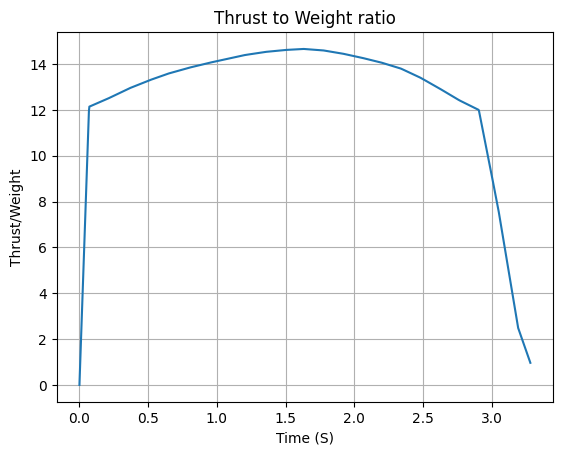

In [174]:
Control_Freak.all_info()


#cm = 74.65 inches
#cp = 82.44 inches

In [175]:
flight = rocketpy.Flight (
     rocket      = Control_Freak,
     environment = env, #env,
     rail_length = 5.18,
     inclination = 90,    #deg — vertical launch
     heading     = 180,   #deg — north
     terminate_on_apogee = False,
)

In [176]:
# Velocity and speed
total_speed = flight.speed
mach_number = flight.mach_number

# Stability indicators
static_margin = flight.static_margin
stability_margin = flight.stability_margin

In [177]:
# 3D trajectory plot
#flight.plots.trajectory_3d()



Initial Conditions

Initial time: 0.000 s
Position - x: 0.00 m | y: 0.00 m | z: 213.00 m
Velocity - Vx: 0.00 m/s | Vy: 0.00 m/s | Vz: 0.00 m/s
Attitude (quaternions) - e0: 0.383 | e1: 0.000 | e2: 0.000 | e3: 0.924
Euler Angles - Spin φ : 67.50° | Nutation θ: 0.00° | Precession ψ: 67.50°
Angular Velocity - ω1: 0.00 rad/s | ω2: 0.00 rad/s | ω3: 0.00 rad/s
Initial Stability Margin: 1.509 c


Surface Wind Conditions

Frontal Surface Wind Speed: -7.08 m/s
Lateral Surface Wind Speed: 4.99 m/s


Launch Rail

Launch Rail Length: 5.18 m
Launch Rail Inclination: 90.00°
Launch Rail Heading: 180.00°


Rail Departure State

Rail Departure Time: 0.307 s
Rail Departure Velocity: 30.133 m/s
Rail Departure Stability Margin: 1.594 c
Rail Departure Angle of Attack: 16.182°
Rail Departure Thrust-Weight Ratio: 12.784
Rail Departure Reynolds Number: 2.767e+05


Burn out State

Burn out time: 3.280 s
Altitude at burn out: 821.476 m (ASL) | 608.476 m (AGL)
Rocket speed at burn out: 328.804 m/s
Freestream vel

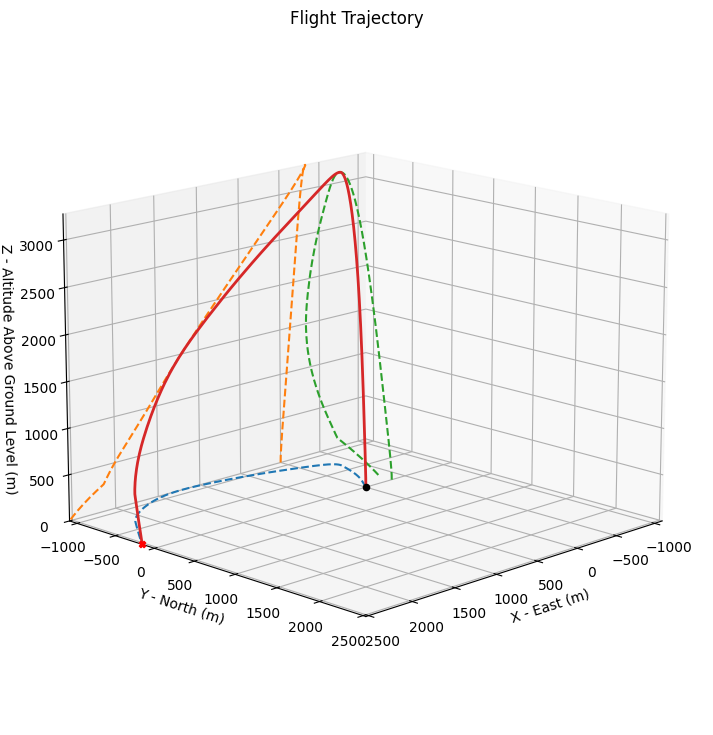



Trajectory Kinematic Plots



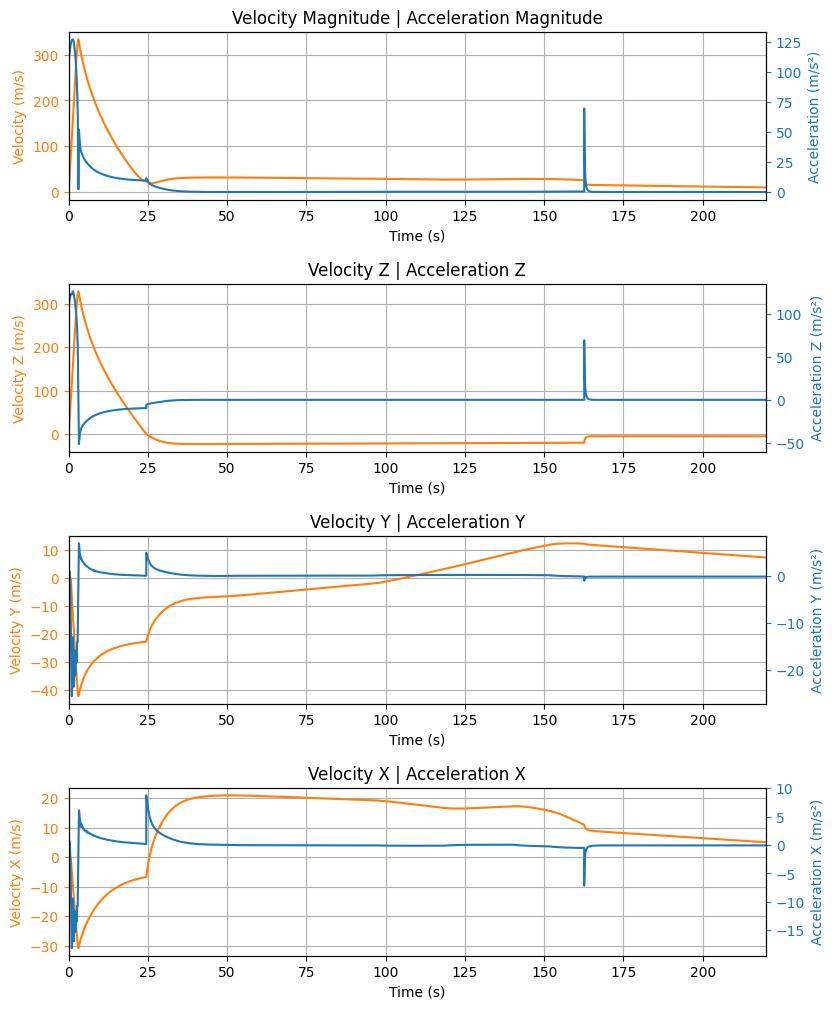



Angular Position Plots



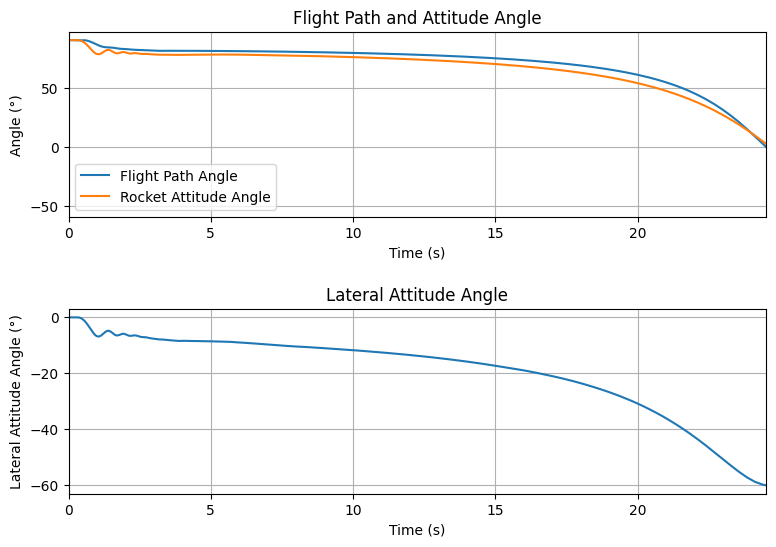



Path, Attitude and Lateral Attitude Angle plots



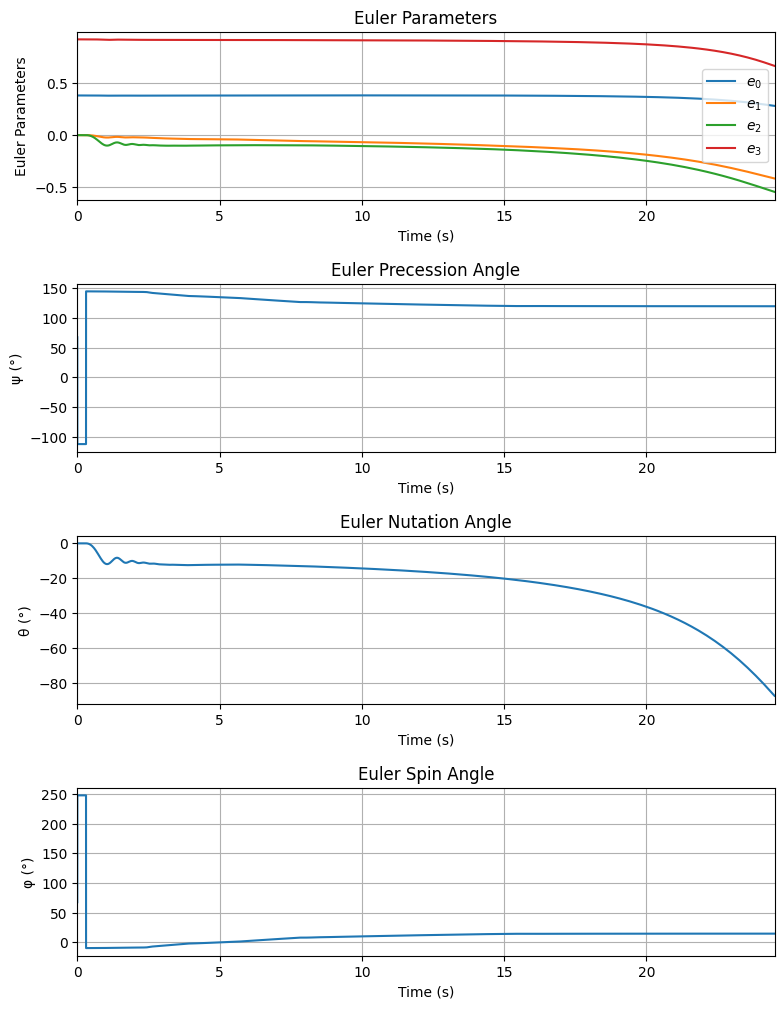



Trajectory Angular Velocity and Acceleration Plots



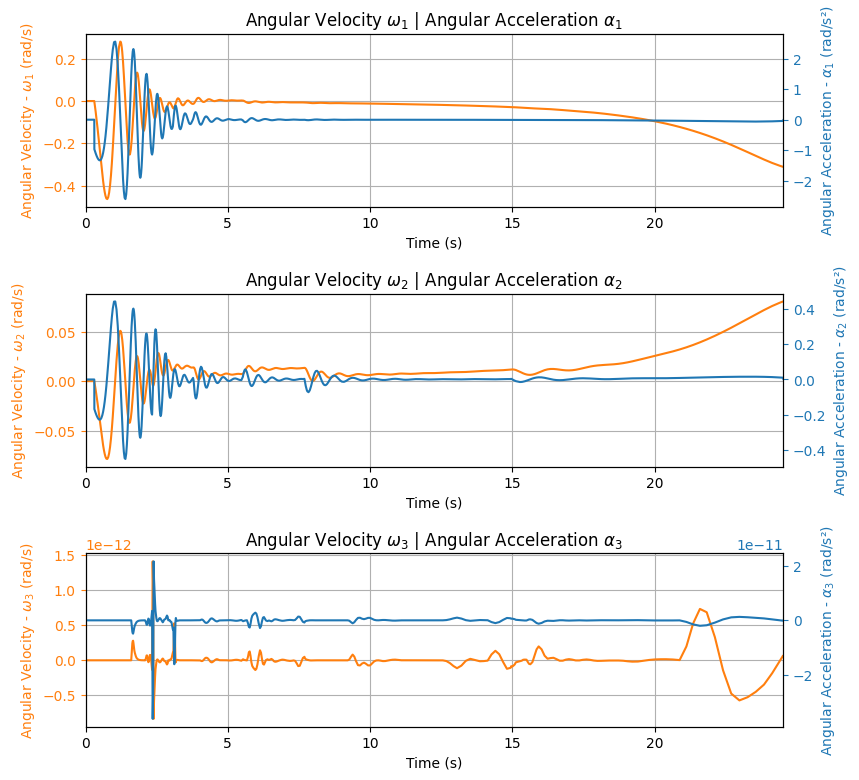



Aerodynamic Forces Plots



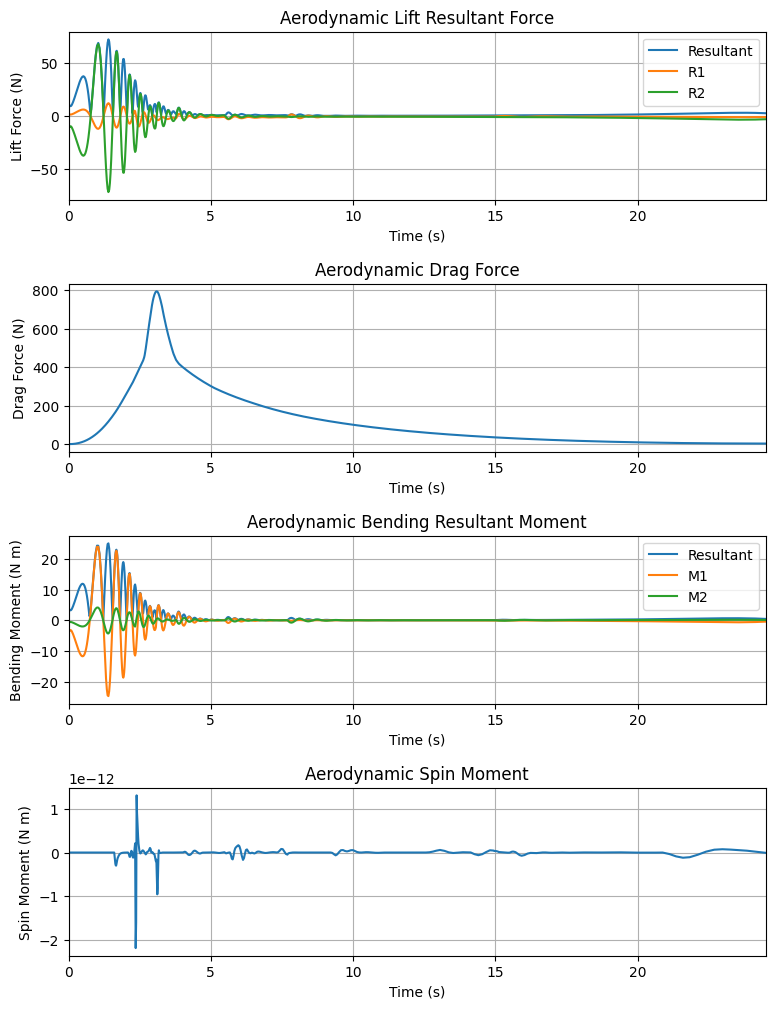



Rail Buttons Forces Plots



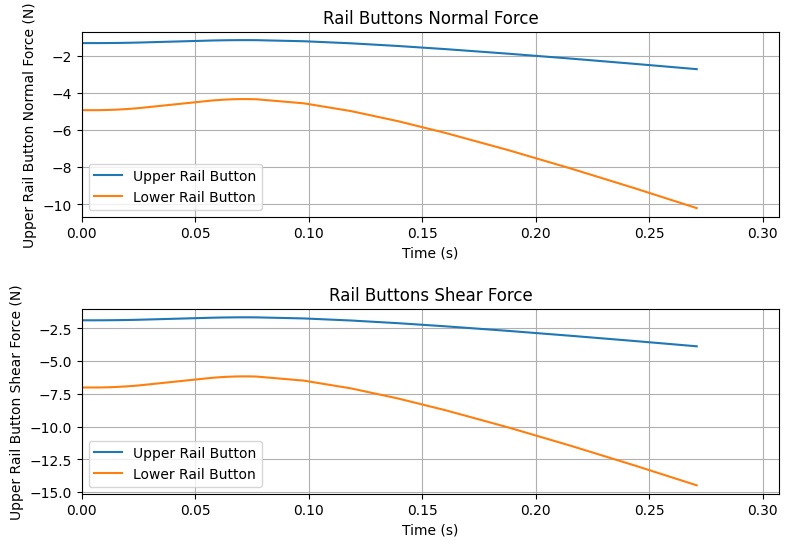



Trajectory Energy Plots



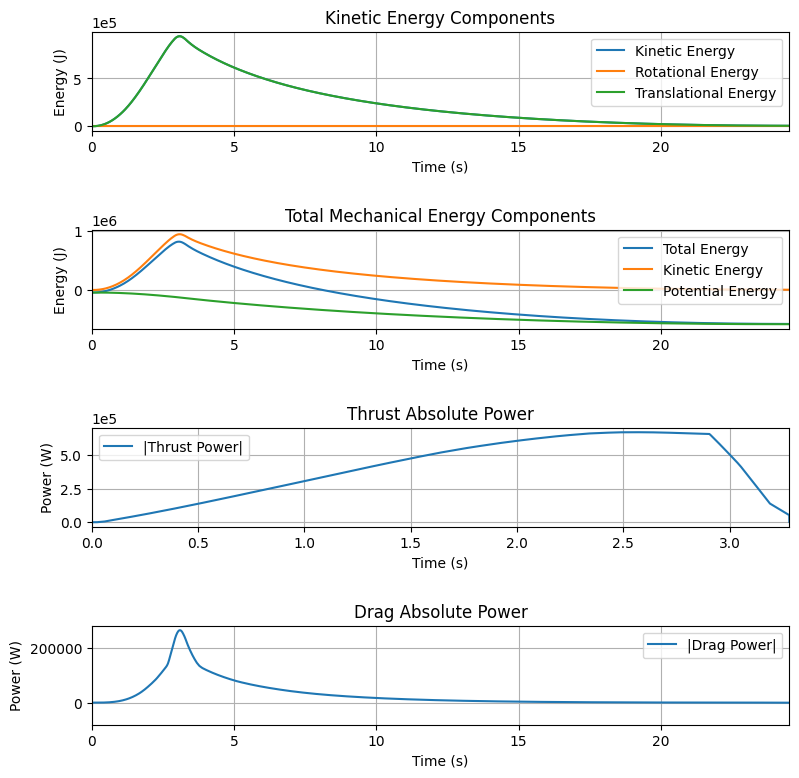



Trajectory Fluid Mechanics Plots



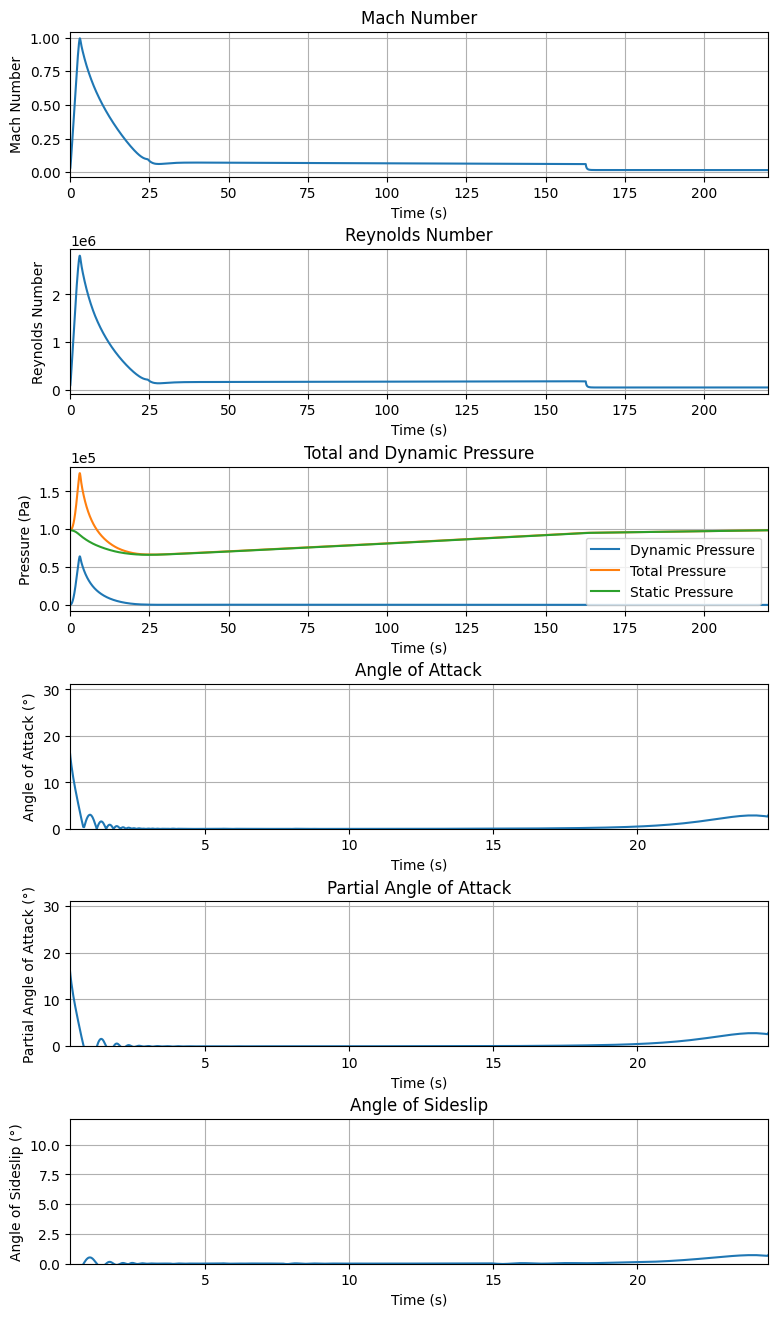



Trajectory Stability and Control Plots



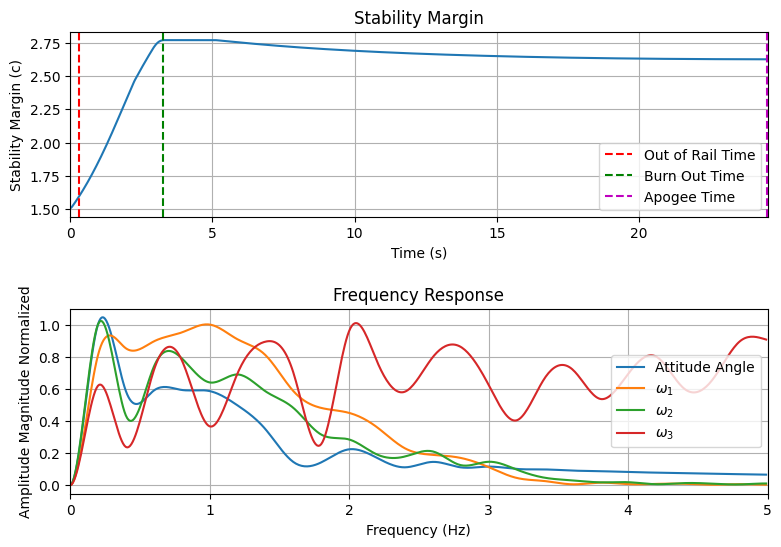



Rocket and Parachute Pressure Plots



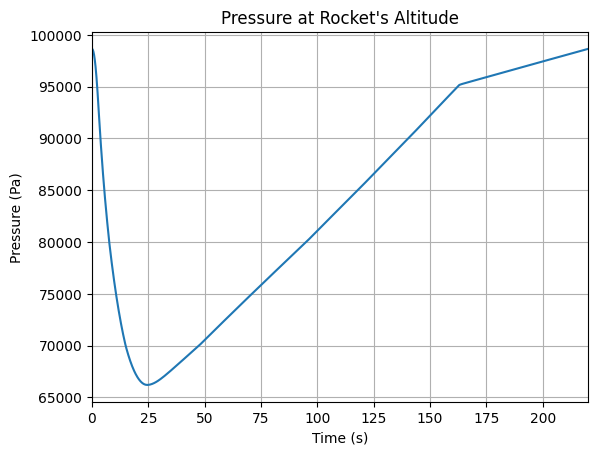


Parachute:  Drogue


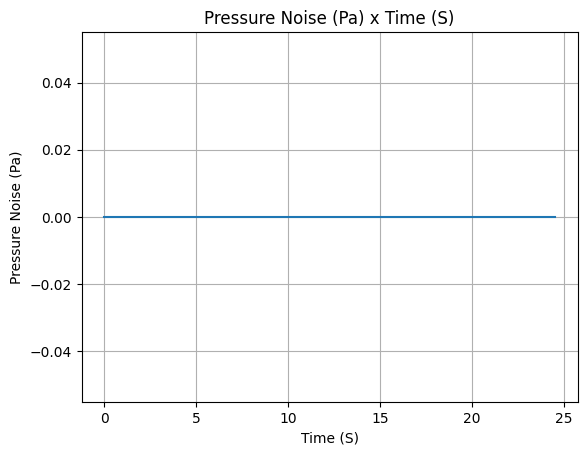

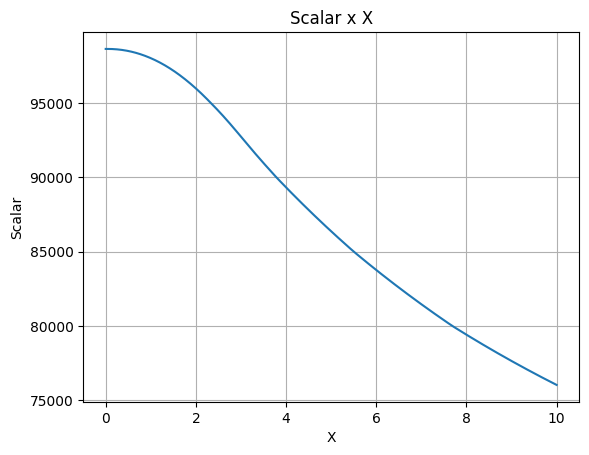

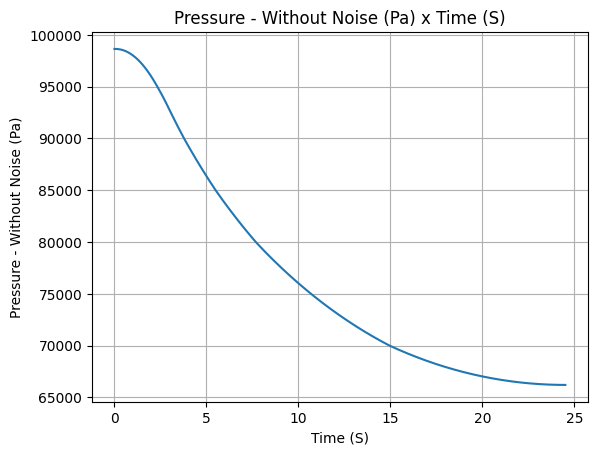


Parachute:  Main


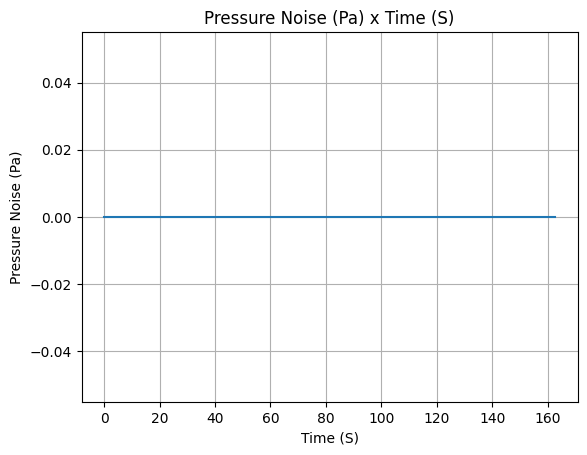

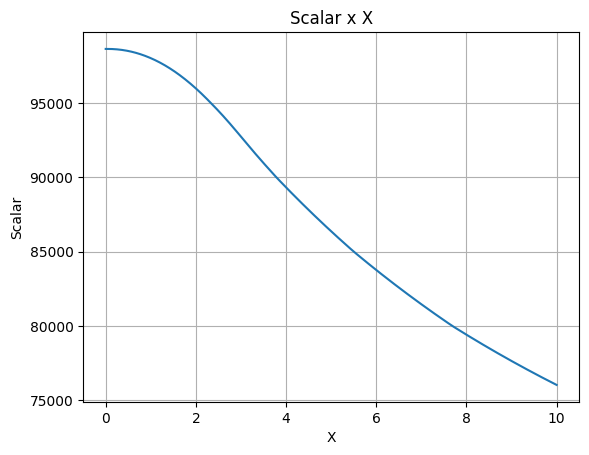

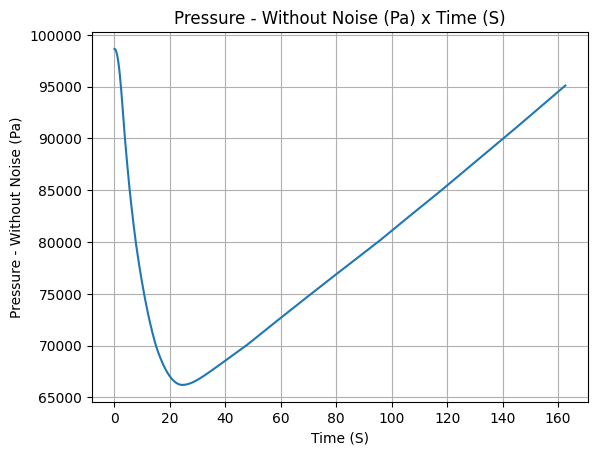

In [178]:
flight.all_info()